# Pipeline B — Virality Predictor

## Plan

| Component | Choice | Citation |
| :--- | :--- | :--- |
| Virality target | K-means on log-normalised subreddit-median-normalised engagement (8.4% viral class) | Barnes et al. (2020); Dogan et al. (2026) |
| Data split | Fakeddit official random splits | Nakamura et al. (2019) |
| Structural metadata | Title word count, temporal (hour bin, day of week, is_weekend), hasImage, caps ratio, punctuation count | Barnes et al. (2020) |
| Domain credibility | MBFC bias and factuality ratings via Idiap Research Institute dataset | Grinberg et al. (2019) |
| Psycholinguistic | NRC EmoLex (8 emotions) + VADER compound — publisher emotion component only | Zhang et al. (2021); Giachanou et al. (2019); Mohammad & Turney (2013); Hutto & Gilbert (2014) |
| Veracity proxy | BERT softmax probabilities (p_true, p_fake_true_text, p_fake_false_text) from Pipeline A | Vosoughi et al. (2018) |
| Political leaning | Phase 1 Fakeddit: keyword density ratio. Phase 2 UK only: Antypas et al. trigger-word counts | Antypas et al. (2026) |
| Interaction term | p_fake x is_low_credibility_domain | Engineered |
| Baseline model | Random Forest | Barnes et al. (2020) |
| Main model | XGBoost with scale_pos_weight for class imbalance | Dogan et al. (2026) |
| Evaluation | PR-AUC (primary), ROC-AUC, F1 at optimal threshold, confusion matrix | Dogan et al. (2026) |
| Explainability | SHAP global summary and interaction plots | Lundberg & Lee (2017); Hashmi et al. (2024) |

## Notes

- Data split: Fakeddit official random splits used rather than chronological. Studying structural and linguistic characteristics that contribute to virality on a static snapshot, not predicting temporal diffusion. Must use same splits as Pipeline A to prevent cross-pipeline contamination.
- Political leaning: BART-MNLI dropped for Phase 1 — US political context unreliable for left/right classification and compute is prohibitive on 564k rows. Simple keyword density ratio used instead. BART-MNLI reserved for Phase 2 UK data only if time allows, otherwise Antypas trigger-word counts are sufficient.
- Social emotion component from Zhang et al. (2021) not implemented — Fakeddit provides comment counts but not comment text. Publisher emotion only. Noted as a limitation.
- Emotion inversion finding: label 0 (True) scores higher than label 2 (Fake/false text) on all emotion dimensions — artefact of label 2 being 85% image-manipulation subreddits with descriptive, emotionally flat captions. Not a theoretical failure. XGBoost contamination risk documented in limitations.
- BERT softmax probabilities from Pipeline A are the cross-pipeline intersection feature connecting Pipeline A and Pipeline B. Must load checkpoint and run inference before feature matrix is complete.
- Interaction term p_fake x is_low_credibility_domain explicitly engineered to make the SHAP attribution of the veracity-credibility interaction directly readable.

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
from datetime import datetime
from zoneinfo import ZoneInfo
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm import tqdm
from datasets import Dataset
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import subprocess
import time
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from pathlib import Path
import xgboost

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
data_dir = os.path.join('..', 'data', 'processed', 'US')

train_path = os.path.join(data_dir, 'multimodal_train.tsv')
val_path = os.path.join(data_dir, 'multimodal_validate.tsv')
test_path = os.path.join(data_dir, 'multimodal_test_public.tsv')

train_df = pd.read_csv(train_path, sep='\t')
val_df = pd.read_csv(val_path, sep='\t')
test_df = pd.read_csv(test_path, sep='\t')

In [7]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


### 1. Virality target construction 

Was going to use VAI (Chauhan et al., 2025) but they rely on post **age**, which I don't have as I'm using static snapshots. Instead, employ the methodology of **Barnes et al. (2020)** from Dank or Not meme paper.

They use feature extraction and then run both random forest and gradient boost models on the fulll feature set. They also use a dataset that's extracted from pushift - same as Fakeddit and my UK dataset so it's a good match.

Highly cited paper (72 citations) so an authoritative source in the research space

Construct virality labels
- Populatiry metric based on upvotes and number of comments - community engagement 
- Chauhan et al. 2025 use upvotes + num_comments in their VAI equation, then divide by age (in hrs). Won't be accounting for age since my snapshot is static. 
- Following Barnes et al (2020), raw engagement scores are normalised to reduce impact of subreddit size. To show why this is necessary, can follow their analysis: "To confirm this observation, we determined the median number of upvotes for each respective subreddit and calculated a Pearson correlation coefficient between these values and the number of subscribers for each subreddit.". **My data doesn't have subreddit subscriber counts, so need to use an alternative method to account for community size. Divide by median raw engagement score for the post's subreddit (acts as proxy for subscriber scale**

`raw_engagement = score + num_comments`

`log_engagement = log(raw_engagement + 1)`

`normalised_engagement = (log_engagement - subreddit_log_mean) / subreddit_log_std`

Justification for raw engagement smoothing method:
- Answers question: how many standard deviations above or below typical is this post's engagement within its own community?
- Raw engagement follows a power law (heavy-tailed og distribution)
- Log transforming makes it approx **normally distributed**, making z-score normalisation valid. **Clip negative scores to 0 to ensure that log transform doesn't produce large negative values - log1p(-1) = -inf, log1p on < -1 = NaN**
- Also means that clustering is in units of standard deviations, which is easily interpretable. 
Follows standard practice for comparing observations across populations with different distributional parameters. Grounded in CLT

Virality threshold determined by k-means
- Following methodology of Dogan et al. 
- K = 2. Clustering algorithm deployed across whole dataset. Segmenting long-tailed distribution into two structural clusters - viral and non-viral. 
- Use 99th percentile outlier cap - k-menas heavily affected by extreme outliers. Apply cap to reduce their effect 
- Ensures threshold dictated by structure of user engagement data rather than unjustified empirical choice. 

In [8]:
def calculate_engagement_metric(df, train_percentile_cap=None, train_subreddit_stats=None):
    """
    Computes each reddit post's normalised engagement score using log z-score within subreddit

    Parameters 
    ----------
    train_percentile_cap : float, optional
        Pre-computed 99th percentile from training set.
        None = compute from this df (use only for train split).
    train_subreddit_stats : dict, optional
        Pre-computed {'mean': Series, 'std': Series} from training set.
        None = compute from this df (use only for train split).
    
    Returns 
    ----------
    df : DataFrame with engagement score column added
    cap_value : 99th percentile threshold (reuse for val/test)
    subreddit_stats : dict of train set subreddit means and stds 

    """

    df = df.copy()

    # raw engagement = num comments + score (num upvotes)
    df['raw_engagement'] = df['num_comments'].fillna(0).clip(lower=0) + df['score'].fillna(0).clip(lower=0)

    # log transform 
    df['log_raw_engagement'] = np.log1p(df['raw_engagement'])

    # z-score within subreddit 
    if train_subreddit_stats is None:   # must be train split to prevent data leakage  - computing threshold 
        sub_means = df.groupby(['subreddit'])['log_raw_engagement'].mean()
        sub_stds = df.groupby(['subreddit'])['log_raw_engagement'].std(ddof=0).fillna(0)
        subreddit_stats = {'mean': sub_means, 'std': sub_stds}
    else:
        subreddit_stats = train_subreddit_stats

    df['sub_mean'] = df['subreddit'].map(subreddit_stats['mean'])
    df['sub_std'] = df['subreddit'].map(subreddit_stats['std'])

    # handle subreddits unseen in training data - fill with total population stats
    df['sub_mean'] = df['sub_mean'].fillna(df['log_raw_engagement'].mean())
    df['sub_std'] = df['sub_std'].fillna(df['log_raw_engagement'].std())

    df['normalised_engagement'] = (df['log_raw_engagement'] - df['sub_mean'])/(df['sub_std'] + 1e-8) # add v small number to avoid dividing by zero when subreddits only have 1 post

    # apply percentile outlier cap to reduce the effects of outliers on k-means. Train set threshold applied to all splits
    if train_percentile_cap is None:
        cap_value = df['normalised_engagement'].quantile(0.99)
    else: 
        cap_value = train_percentile_cap

    df['capped_engagement'] = np.minimum(df['normalised_engagement'], cap_value) # use what's smaller of engagement number or percentile cap 

    # remove intermediate cols
    df = df.drop(columns=['sub_mean', 'sub_std'])
    
    return df, cap_value, subreddit_stats


In [9]:
def plot_engagement_dist(df, threshold):
    plot_df = pd.DataFrame({
        'Capped_Normalised_Engagement': df['capped_engagement'],
        'Class': df['is_viral'].map({0: "Non-Viral (0)", 1: 'Viral (1)'})
    })

    plt.figure(figsize=(8, 5))
    sns.set_theme(style='whitegrid')

    sns.histplot(
        data=plot_df,
        x='Capped_Normalised_Engagement',
        hue='Class',
        palette={'Non-Viral (0)': '#3498db', 'Viral (1)': '#e74c3c'},
        bins=50
    )

    # virality threshold line 
    plt.axvline(
        x=threshold, 
        color='#2c3e50',
        linestyle='--',
        linewidth=2.5,
        label=f'Virality Threshold ({threshold:.2f})'
    )

    plt.title('Data-Driven Virality Partitioning (Dogan et al. 2026 Framework)', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Capped Normalised Engagement [ln(x + 1)]', fontsize=12, labelpad=10)
    plt.ylabel('Post Count (Frequency)', fontsize=12, labelpad=10)

    plt.legend(title='Class', title_fontsize='11', loc='upper right', frameon=True)

    plt.tight_layout()
    plt.show()



In [10]:
def calculate_engagement_threshold_k_means(df, train_percentile_cap=None, train_subreddit_stats=None, train_threshold=None, graph=True):
    """
    Computes binary virality threshold based on k-means clustering on normlaised engagement score 
    """

    df, cap_value, subreddit_stats = calculate_engagement_metric(
        df,
        train_percentile_cap=train_percentile_cap,
        train_subreddit_stats=train_subreddit_stats
        )
    
    engagement_values = df['capped_engagement'].values

    if train_threshold is None: 
        # For TRAIN set - fit K-means to find virality boundary
        # reshape for scikit-learn
        engagement_matrix = engagement_values.reshape(-1, 1)

        # train k-means with 2 clusters - viral vs non-viral
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        df['cluster_labels'] = kmeans.fit_predict(engagement_matrix)

        # map cluster labels to 'is_viral' df col
        cluster_centres = kmeans.cluster_centers_.flatten()
        viral_clusters = np.argmax(cluster_centres)     # seeing which cluster has the higher engagement metrics

        df['is_viral'] = (df['cluster_labels'] == viral_clusters).astype(int)

        threshold = np.mean(cluster_centres)
        print(f'K-means virality threshold: {threshold:.4f}')
    
    else: 
        # VAL/TEST - apply training threshold, do not refit 
        threshold = train_threshold
        df['is_viral'] = (df['capped_engagement'] >= threshold).astype(int)
        print(f'Applied training threshold: {threshold:.4f}')

    print(f'Class distribution: {df['is_viral'].value_counts(normalize=True).round(3).to_dict()}')

    if graph:
        plot_engagement_dist(df, threshold)


    cols_to_drop = ['cluster_labels', 'log_raw_engagement', 'capped_engagement', 'raw_engagement']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df, threshold, cap_value, subreddit_stats

- Initially applied 99% cap as done in paper, but viral class too small, too still heavily affected by outliers. Acute class imbalance would make downstream supervised learning difficult (justify)
- To further smooth the long tail variance, a natural log transformation was applied (ln(x+1))

K-means virality threshold: 0.4990
Class distribution: {0: 0.77, 1: 0.23}


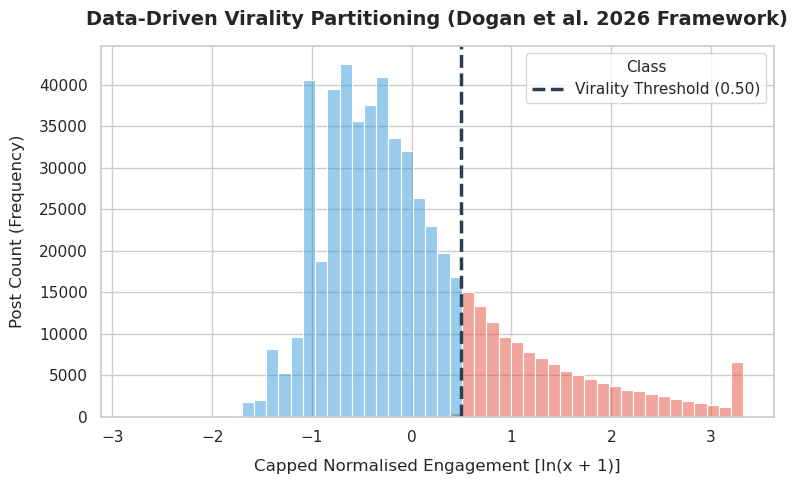

In [11]:
train_df, threshold, cap_value, sub_stats = calculate_engagement_threshold_k_means(train_df, graph=True)

Can't justify using k means clustering on the z-normlaised dataset because it is unomodal and there's no clear threshold. Would only need a raw engagement score of arround 55 to be 'viral' - too low. Instead, revert to the top 20% threshold used by Barnes et al. (sp this approach is consistent with prior work in social media virality prediction)

- Produces a class balance suitable for supervised learning 
- z-score normalisation accounts for varied subreddit community sizes

**DROP K MEANS**


In [12]:
def apply_virality_threshold(df, train_percentile_cap=None,
                              train_subreddit_stats=None,
                              train_threshold=None,
                              viral_percentile=0.80,
                              graph=True):
    df, cap_value, subreddit_stats = calculate_engagement_metric(
        df,
        train_percentile_cap=train_percentile_cap,
        train_subreddit_stats=train_subreddit_stats,
    )

    if train_threshold is None:
        threshold = df['capped_engagement'].quantile(viral_percentile)
    else:
        threshold = train_threshold

    df['is_viral'] = (df['capped_engagement'] >= threshold).astype(int)

    print(f'Virality threshold (z-score): {threshold:.4f}')
    print(f'Class distribution:\n{df["is_viral"].value_counts(normalize=True).round(3)}')

    if graph:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        df['capped_engagement'].hist(bins=100, ax=axes[0])
        axes[0].axvline(threshold, color='red', linestyle='--',
                        label=f'threshold={threshold:.2f}')
        axes[0].set_title('Normalised engagement distribution')
        axes[0].set_xlabel('z-score (capped)')
        axes[0].legend()

        df['log_raw_engagement'].hist(bins=100, ax=axes[1])
        axes[1].set_title('Log raw engagement distribution')
        axes[1].set_xlabel('log(raw_engagement + 1)')

        plt.tight_layout()
        plt.show()

        overall_mean = df['log_raw_engagement'].mean()
        overall_std  = df['log_raw_engagement'].std()
        approx_raw_eng = np.expm1(threshold * overall_std + overall_mean)
        print(f"Approx raw engagement at threshold: {approx_raw_eng:.0f} (upvotes + comments)")

    # drop intermediate columns after plotting
    df = df.drop(columns=[c for c in ['capped_engagement', 'log_raw_engagement',
                                       'raw_engagement'] if c in df.columns])

    return df, threshold, cap_value, subreddit_stats

Apply threshold calculated on training set to validation and test sets. Important that threshold is not recalculated so that there is no data leakage in the pipeline. No info from the test set influences the definition of virality. 

Virality threshold (z-score): 0.6384
Class distribution:
is_viral
0    0.8
1    0.2
Name: proportion, dtype: float64


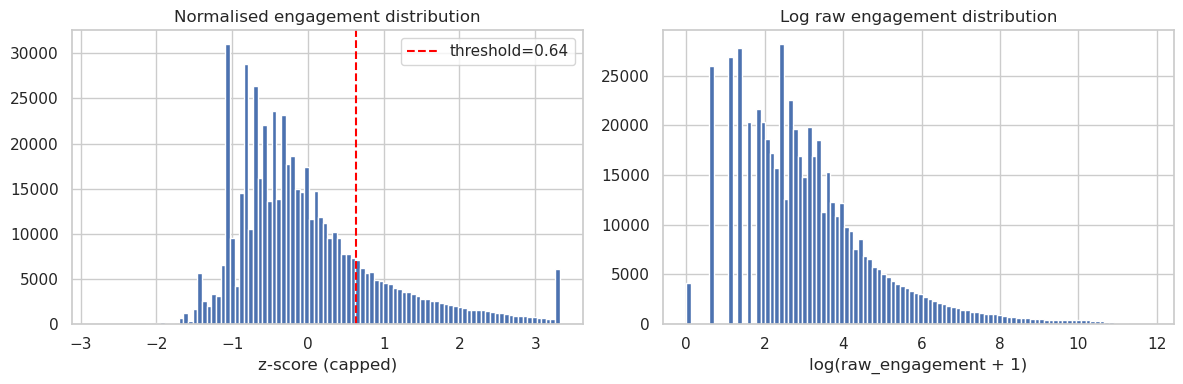

Approx raw engagement at threshold: 71 (upvotes + comments)


In [13]:
train_df, threshold, cap_value, sub_stats = apply_virality_threshold(
    train_df, graph=True
)

Virality threshold (z-score): 1.3551
Class distribution:
is_viral
0    0.9
1    0.1
Name: proportion, dtype: float64


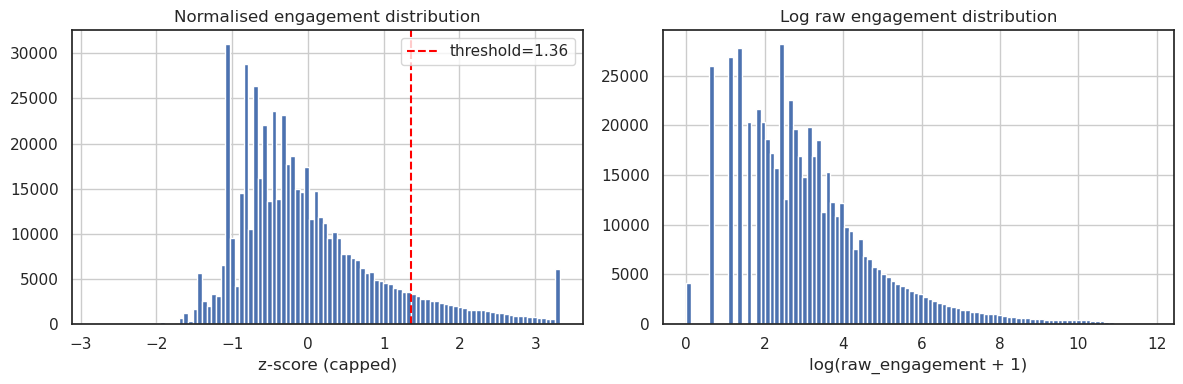

Approx raw engagement at threshold: 252 (upvotes + comments)


In [27]:
train_df, threshold, cap_value, sub_stats = apply_virality_threshold(
    train_df, viral_percentile=0.90, graph=True
)

In [28]:
val_df, _, _, _ = apply_virality_threshold(
    val_df,
    train_percentile_cap=cap_value,
    train_subreddit_stats=sub_stats,
    train_threshold=threshold,
    graph=False,
)

test_df, _, _, _ = apply_virality_threshold(
    test_df,
    train_percentile_cap=cap_value,
    train_subreddit_stats=sub_stats,
    train_threshold=threshold,
    graph=False,
)

Virality threshold (z-score): 1.3551
Class distribution:
is_viral
0    0.9
1    0.1
Name: proportion, dtype: float64
Virality threshold (z-score): 1.3551
Class distribution:
is_viral
0    0.898
1    0.102
Name: proportion, dtype: float64


In [29]:
artefacts = {
    'threshold': threshold,
    'cap_value': cap_value,
    'viral_percentile': 0.80,
    'sub_stats_mean': sub_stats['mean'].to_dict(),
    'sub_stats_std': sub_stats['std'].to_dict(),
}

Path('../data/processed/US').mkdir(parents=True, exist_ok=True)
with open('../data/processed/US/virality_artefacts.json', 'w') as f:
    json.dump(artefacts, f, indent=2)
print('Artefacts saved')

Artefacts saved


**Virality target — final summary**
- Normalisation: log z-score within subreddit (clip scores to 0, ddof=0 std)
- Outlier cap: 99th percentile from training set
- Threshold: 90th percentile of normalised engagement on training set
  (z = 1.36, approx raw engagement = 252 upvotes + comments)
- Class distribution: 90% non-viral, 10% viral (consistent across splits)
- Justification: a z-score threshold of ~1.36 places the virality boundary 
  at more than one standard deviation above the subreddit mean, consistent 
  with the statistical definition of an exceptional observation. The 90th 
  percentile operationalises this: viral posts are those in the top decile 
  of normalised engagement within their community.
- K-means rejected: distribution is unimodal — degenerates to median split
- Barnes et al. (2020) use a top-5% threshold; I'm using a top-10% 
  definition to ensure the viral class captures genuinely exceptional 
  engagement rather than posts that just have above-average engagement (z score of around 1.35). **DO I NEED TO CHANGE THIS TO 5%????**

### 2. Feature engineering

Extracting additional features to enrich dataset and allow for discussion of factors leading to virality.

Already have binary true/fake misinofrmation flag from the labelled fakeddit dataset for US. If found to be an important feature, the BERT model I've trained will br used to extract these labels for UK data. 

#### 2.1 Structural Metadata

**Temporal metadata**

Controls for time-based cycles Reddit platform traffic and user engagement


Following methodology of Dank or Not (Barnes et al.). Timestamp for when post first appeared on Reddit is in the Coordinated Universal Time zone (UTC). For Fakeddit, assume majority of posts created in US, so convert to North American Central Time zone, as they do in paper. For UK subreddits, convert to GMT. 

Then extract
- Time of day (in 4 hour bins)
- Day of week 
- Is weekend flag

In [30]:
def add_timezone_features(utc_val, country):
    if country == 'US': 
        timezone = 'America/Chicago'
    if country == 'UK':
        timezone = 'Europe/London'

    dt = datetime.fromtimestamp(utc_val, tz=ZoneInfo('UTC'))
    local_dt = dt.astimezone(tz=ZoneInfo(timezone))


    day_of_week = local_dt.weekday()
    is_weekend = local_dt.weekday in (5,6)
    hour_bin = local_dt.hour // 4

    bin_labels = {
    0: '12 am-4 am',
    1: '4 am-8 am',
    2: '8 am-12 pm',
    3: '12 pm-4 pm',
    4: '4 pm-8 pm',
    5: '8 pm-12 am'
    }

    time_of_day = bin_labels.get(hour_bin)

    return pd.Series([day_of_week, is_weekend, time_of_day])

In [31]:
for df in [train_df, val_df, test_df]:
    df[['day_of_week', 'is_weekend', 'time_of_day']] = df['created_utc'].apply(add_timezone_features, args=('US',))

train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,title_word_count,processed_words,bias_left,bias_left_center,bias_neutral,bias_right_center,bias_right,factuality_high,factuality_mixed,factuality_low
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,15,"[walgreen, offbrand, mucinex, engrav, letter, ...",0,0,0,0,0,0,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,7,"[concern, sink, tini, hat]",0,0,0,0,0,0,0,0
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,8,"[hacker, leak, email, uae, ambassador, us]",0,1,0,0,0,0,1,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,5,"[puppi, take, view]",0,0,0,0,0,0,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,9,"[found, face, sheet, music]",0,0,0,0,0,0,0,0


Text(0.5, 0, 'Normalised Engagement Score')

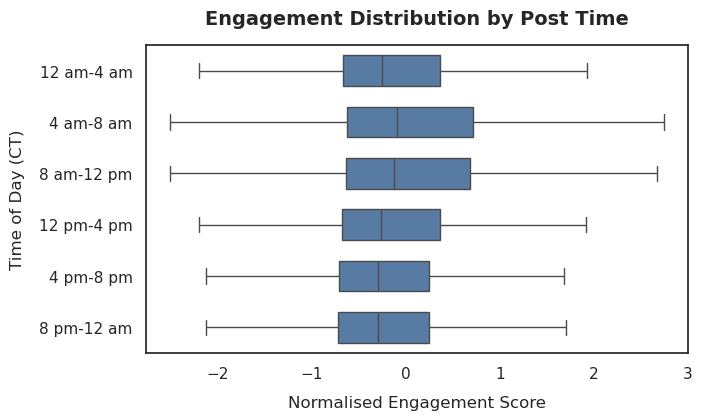

In [32]:
bin_labels = {
    0: '12 am-4 am',
    1: '4 am-8 am',
    2: '8 am-12 pm',
    3: '12 pm-4 pm',
    4: '4 pm-8 pm',
    5: '8 pm-12 am'
}

bin_order = ['12 am-4 am', '4 am-8 am', '8 am-12 pm', '12 pm-4 pm', '4 pm-8 pm','8 pm-12 am']

sns.set_theme(style='white')
plt.figure(figsize=(7,4))

ax = sns.boxplot(
    data=train_df,
    x='normalised_engagement',
    y='time_of_day',
    color='#4A7BB0',
    width=0.6,
    showfliers=False,
    order=bin_order
)

plt.title('Engagement Distribution by Post Time', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Time of Day (CT)', fontsize=12, labelpad=10)
plt.xlabel('Normalised Engagement Score', fontsize=12, labelpad=10)



**HasImage (Adapting Barnes et al., 2020):** Incorporate `hasImage` binary flag - native to Fakeddit but not to pushift dumps used for UK. Can engineer for UK - mark post as HasImage = 1 if url col includes an image extension (.jpg, .jpeg, .png, .gif) or if post_hint = image. Otherwise 0


**Word count**

Number of words in Fakeddit `clean title` column


In [18]:
def get_title_word_count(df, column):
    df['title_word_count'] = df.loc[:, column].str.split().str.len()

    return df

train_df = get_title_word_count(train_df, 'clean_title')
train_df.head()


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,upvote_ratio,2_way_label,3_way_label,6_way_label,normalised_engagement,is_viral,day_of_week,is_weekend,time_of_day,title_word_count
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,0.84,1,0,0,-0.396417,0,6,False,12 pm-4 pm,15
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,0.99,0,2,2,1.334576,1,6,False,8 pm-12 am,7
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,0.92,1,0,0,0.316272,0,5,False,12 pm-4 pm,8
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,0.95,1,0,0,1.275603,1,1,False,4 am-8 am,5
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,0.84,0,2,2,0.008301,0,2,False,8 pm-12 am,9


**Processed text**

As in Dank or Not paper, all text associated with the post (for Fakeddit this is just `cleaned text`) undergoes tokenisation, lemmatisation, and stemming. Paper uses NTLK and emsim - references Rehurek and Sojka 2011; Loper and Bird 2002

In [19]:
def clean_and_stem_text(text):
    if not isinstance(text, str):
        return []
    
    # lowercase and remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # tokenise and remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in text.split() if word not in stop_words]
    # stemming (same as Barnes et al.)
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in tokens]

In [20]:
train_df['processed_words'] = train_df['clean_title'].apply(clean_and_stem_text)

**Domain Credibility**

Cross check domains against verfied lost of websites and heir credibility ratings. Use MBFC (Media Bias Fact Check - https://mediabiasfactcheck.com/) official ratings for `bias` and `factual reporting`. CSV is from Idiap Research Institute's github - from paper **Mapping the Media Landscape: Predicting Factual Reporting and Political Bias Through Web Interactions**

In [21]:
# load MBFC dataset
idiamap_mbfc_url = 'https://raw.githubusercontent.com/idiap/Factual-Reporting-and-Political-Bias-Web-Interactions/main/data/mbfc.csv'
mbfc_df = pd.read_csv(idiamap_mbfc_url)
mbfc_df.head()


,source,bias,factual_reporting
0,9news.com,neutral,high
1,nbc11news.com,neutral,high
2,12news.com,neutral,high
3,wibw.com,neutral,high
4,wifr.com,neutral,high


In [22]:
# check uk domains present 
uk_targets = ['theguardian.com', 'independent.co.uk', 'gbnews.uk', 'bbc.co.uk', 'dailymail.co.uk']
uk_check = mbfc_df[mbfc_df['source'].isin(uk_targets)]
print(uk_check)

# check major us domains present
us_targets = ['nytimes.com', 'foxnews.com', 'breitbart.com', 'washingtonpost.com', 'thegatewaypundit.com']
us_check = mbfc_df[mbfc_df['source'].isin(us_targets)]
print(us_check)

                 source         bias factual_reporting
1704    theguardian.com  left-center             mixed
1708  independent.co.uk  left-center             mixed
1722    theguardian.com  left-center             mixed
2764    dailymail.co.uk        right               low
2868          gbnews.uk        right             mixed
                    source         bias factual_reporting
1600           nytimes.com  left-center              high
1806    washingtonpost.com  left-center             mixed
2681         breitbart.com        right             mixed
2854           foxnews.com        right             mixed
3370  thegatewaypundit.com        right               low


One-hot encode mbfc columns so that they can be used in the feature matrix for XGBoost

In [23]:
# add MBFC domain credibility features to all three splits

# clean source column in MBFC lookup table
mbfc_df['source_clean'] = (mbfc_df['source']
                           .str.lower()
                           .str.strip()
                           .str.replace('www.', '', regex=False))

bias_map        = dict(zip(mbfc_df['source_clean'], mbfc_df['bias']))
factuality_map  = dict(zip(mbfc_df['source_clean'], mbfc_df['factual_reporting']))

NATIVE_REDDIT_DOMAINS = {'reddit.com', 'v.redd.it', 'i.redd.it', 'i.imgur.com'}

def add_mbfc_features(df, bias_map, factuality_map, split_name=''):
    df = df.copy()

    # clean domain for matching
    df['domain_clean'] = (df['domain']
                          .str.lower()
                          .str.strip()
                          .str.replace('www.', '', regex=False))

    # map bias and factuality
    df['mbfc_bias']       = df['domain_clean'].map(bias_map).fillna('unknown_unrated')
    df['mbfc_factuality'] = df['domain_clean'].map(factuality_map).fillna('unknown_unrated')

    # override with native_reddit where applicable
    is_native = (
        df['domain_clean'].str.contains(r'self\.', na=False) |
        df['domain_clean'].isin(NATIVE_REDDIT_DOMAINS)
    )
    df.loc[is_native, ['mbfc_bias', 'mbfc_factuality']] = 'native_reddit'

    # value counts for sparsity notes
    print(f"{split_name} ({len(df):,} rows)")
    print("mbfc_bias:")
    print(df['mbfc_bias'].value_counts().to_string())
    print("\nmbfc_factuality:")
    print(df['mbfc_factuality'].value_counts().to_string())
    rated = (~df['mbfc_bias'].isin(['unknown_unrated', 'native_reddit'])).sum()
    print(f"\nPosts with MBFC rating: {rated:,} ({100*rated/len(df):.1f}%)")
    print(f"Posts without rating:   {len(df)-rated:,} ({100*(len(df)-rated)/len(df):.1f}%)\n")

    # one-hot encode bias
    df['bias_left']         = (df['mbfc_bias'] == 'left').astype(int)
    df['bias_left_center']  = (df['mbfc_bias'] == 'left-center').astype(int)
    df['bias_neutral']      = (df['mbfc_bias'] == 'neutral').astype(int)
    df['bias_right_center'] = (df['mbfc_bias'] == 'right-center').astype(int)
    df['bias_right']        = (df['mbfc_bias'] == 'right').astype(int)

    # one-hot encode factuality
    df['factuality_high']  = (df['mbfc_factuality'] == 'high').astype(int)
    df['factuality_mixed'] = (df['mbfc_factuality'] == 'mixed').astype(int)
    df['factuality_low']   = (df['mbfc_factuality'] == 'low').astype(int)

    # drop intermediate columns — keep raw strings for reference until confirmed
    df.drop(columns=['domain_clean', 'mbfc_bias', 'mbfc_factuality'], inplace=True)

    return df


train_df = add_mbfc_features(train_df, bias_map, factuality_map, split_name='train')
val_df   = add_mbfc_features(val_df,   bias_map, factuality_map, split_name='val')
test_df  = add_mbfc_features(test_df,  bias_map, factuality_map, split_name='test')

train (564,000 rows)
mbfc_bias:
mbfc_bias
unknown_unrated    258328
native_reddit      253443
left-center         27513
neutral             12210
left                 4635
right-center         4481
right                3390

mbfc_factuality:
mbfc_factuality
unknown_unrated    258328
native_reddit      253443
high                34046
mixed               17383
low                   800

Posts with MBFC rating: 52,229 (9.3%)
Posts without rating:   511,771 (90.7%)

val (59,342 rows)
mbfc_bias:
mbfc_bias
unknown_unrated    27389
native_reddit      26586
left-center         2792
neutral             1311
left                 475
right-center         439
right                350

mbfc_factuality:
mbfc_factuality
unknown_unrated    27389
native_reddit      26586
high                3507
mixed               1775
low                   85

Posts with MBFC rating: 5,367 (9.0%)
Posts without rating:   53,975 (91.0%)

test (59,319 rows)
mbfc_bias:
mbfc_bias
unknown_unrated    27063
native_reddit   

Majority of posts are `unknown_unrated` or `native_reddit` - accounts for over 90% of training data. For US data, these signals may be weak - could be different for UK. Need to bear sparsity in mind 

In [24]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,title_word_count,processed_words,bias_left,bias_left_center,bias_neutral,bias_right_center,bias_right,factuality_high,factuality_mixed,factuality_low
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,15,"[walgreen, offbrand, mucinex, engrav, letter, ...",0,0,0,0,0,0,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,7,"[concern, sink, tini, hat]",0,0,0,0,0,0,0,0
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,8,"[hacker, leak, email, uae, ambassador, us]",0,1,0,0,0,0,1,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,5,"[puppi, take, view]",0,0,0,0,0,0,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,9,"[found, face, sheet, music]",0,0,0,0,0,0,0,0


#### 2.2 Psycholinguistic features

**Research question:** do misinformation posts go viral for different emotional reasons than factual posts? → requires emotional granularity, not just polarity

**Why not Barnes et al. approach?**
- Barnes et al. (2020) use Liu & Zhang (2012) opinion lexicon → coarse positive/negative/neutral only
- Cannot distinguish anger vs fear vs disgust → SHAP analysis would be uninterpretable

**Framework: Zhang et al. (2021, WWW) — "Mining Dual Emotion for Fake News Detection"**
- Most cited recent framework for emotion + fake news
- Publisher emotion (post text) + social emotion (comments) → dual emotion
- Social emotion and emotion gap shown to matter more than publisher emotion alone
- **Implementing publisher emotion component only** — Fakeddit has comment counts but not comment text, so social emotion is unavailable. Noted as a limitation.
- Publisher emotion features in Zhang et al.: emotion category, emotional lexicon, emotional intensity, sentiment score, auxiliary (punctuation/caps)
- Implementing **emotional lexicon** (EmoLex) + **sentiment score** (VADER) components — sufficient for tabular XGBoost feature matrix without additional classifiers

**Tool 1 — NRC Word-Emotion Association Lexicon (EmoLex; Mohammad & Turney, 2013)**
- 8 discrete emotions: anger, fear, joy, trust, disgust, sadness, anticipation, surprise
- Returns proportion of matched words per emotion (`affect_frequencies`) — already normalised by word count
- Granularity enables SHAP to distinguish which specific emotions drive viral misinfo vs viral truth
- Used in Giachanou et al. (2019, SIGIR) for credibility detection — directly justifies lexicon choice
- Vosoughi et al. (2018): false news triggers fear, disgust, surprise; true news triggers joy, trust, anticipation → theoretical motivation for these specific dimensions

**Tool 2 — VADER compound sentiment score (Hutto & Gilbert, 2014)**
- Single compound score [-1, 1]
- Designed for social media text — handles capitalisation, punctuation, slang
- Complements EmoLex: captures aggregate valence where EmoLex has no lexicon match (e.g. political proper nouns "Starmer", "NHS", "Brexit" return zero NRC scores but VADER scores surrounding language)
- Implements Zhang et al.'s sentiment score component

**Citation roles**
- Zhang et al. (2021, WWW) — framework being implemented (publisher emotion, emotional lexicon + sentiment score)
- Giachanou et al. (2019, SIGIR) — theoretical justification that granular emotion categories outperform sentiment polarity for credibility detection; uses EmoLex directly
- Mohammad & Turney (2013) — NRC EmoLex tool citation
- Hutto & Gilbert (2014) — VADER tool citation
- Vosoughi et al. (2018, Science) — theoretical motivation: false news is more emotionally charged and propagates differently from true news across all valence dimensions

**Note on Giachanou et al. citation:** their implementation is architectural (LSTM), not tabular — cite for theoretical motivation and lexicon justification only, not for the specific feature engineering approach

In [35]:
vader = SentimentIntensityAnalyzer()

# 8 emotions from EmoLex
nrc_emotions = ['anger', 'fear', 'joy', 'trust', 'disgust', 'sadness', 'anticipation', 'surprise']

_nrc = NRCLex()

def extract_emotion_features(text):
    """
    Extract NRC Emolex emotion proportions (col 0-1 for each emotion) and VADER compound sentiment (-1 to 1)

    """

    # account for empty/null input
    if not isinstance(text, str) or not text.strip():
        return {f'emo_{e}': 0.0 for e in nrc_emotions} | {'vader_component': 00}


    _nrc.load_raw_text(text)
    freq = _nrc.affect_frequencies # proportion 0-1 for each emotion 


    vs = vader.polarity_scores(text)

    return (
        {f'emo_{e}': freq.get(e, 0) for e in nrc_emotions} | 
        {'vader_compound': vs['compound']}
    )

In [36]:
# Check to see if outputs look sensible before full run 

spot_check_texts = [
    "Starmer slammed for betraying working class voters",
    "Government announces record NHS funding boost",
    "Rioters attack mosque in shocking scenes of violence",
    "Study finds immigrants commit more crime says report",
    "Local charity raises money for flood victims",
    "",    # empty — should return all zeros
    None,  # null — should return all zeros
]
 
print("=== Spot-check: emotion features on sample titles ===\n")
for text in spot_check_texts:
    feats = extract_emotion_features(text)
    nonzero = {k: round(v, 3) for k, v in feats.items() if v != 0.0}
    print(f"  Text: {repr(str(text)[:60])}")
    print(f"  Non-zero features: {nonzero}\n")

=== Spot-check: emotion features on sample titles ===



MissingCorpusError: 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.


Demonstrates limitiation of EmoLex - operates at word level, doesn't use overall context of text. Local charity raises money for flood victims is positive but 'flood' and 'victims' result in fear and anger scores.

Scores won't necessarily sum to 1 - `affect_frequencies` normalises by total word count in text, so if only 6 out of 9 words in the title match an emotion in the lexicon, the resulting emotion proportions will only add to 0.66

In [ ]:
text_col = 'clean_title'

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'Processing {name}: {len(df)} rows')
    start = time.time()

    emo_features = pd.DataFrame(
        df[text_col].apply(extract_emotion_features).tolist(),
        index=df.index
    )

    # join emo features back to original df
    for col in emo_features.columns:
        df[col] = emo_features[col]
    
    end = time.time()
    elapsed = end - start
    print(f'Finished in {elapsed:2f}s')

emo_cols = [f'emo_{e}' for e in nrc_emotions] + ['vader_compound']
print(f"\nNew columns: {emo_cols}")
print(f"\nTrain set — mean emotion scores:")
print(train_df[emo_cols].mean().round(4).to_string())
print(f"\nNull counts: {train_df[emo_cols].isnull().sum().sum()} (should be 0)")

In [ ]:
# Do misinformation posts have higher anger/fear than authentic posts? Theoretical prediction is yes. If not, worth investigating before training XGBoost.
 
print('\nMean emotion scores by 3-way veracity classification')
print("({0: 'True', 1: 'Fake (true text / propaganda)', 2: 'Fake (false text / manipulated)'")
print(
    train_df.groupby('3_way_label')[emo_cols]
    .mean()
    .round(4)
    .to_string()
)

**Emotion distribution by veracity class (train set)**
Labels: 0 = True (222k), 1 = Fake/true text — propaganda only (14k), 2 = Fake/false text — image manipulation + satire (328k)
Primary comparison for downstream analysis: **label 0 (true) vs label 2 (false image and text)**

- Label 2 scores *lower* than label 0 on nearly all emotion dimensions — counterintuitive given misinformation literature
- `emo_fear`: label 0 (0.065) > label 2 (0.049) — true content more fear-laden than fake/false text
- `emo_trust`: label 0 (0.103) > label 2 (0.065) — true content scores substantially higher
- `emo_joy`: label 0 (0.058) > label 2 (0.041) — same direction
- `vader_compound`: label 0 (+0.014) > label 2 (+0.009) — both mildly positive, minimal difference
- **Explanation:** label 2 is dominated by image-manipulation subreddits (`psbattle_artwork` 168k, `pareidolia` 47k, `fakehistoryporn` 36k) — titles are mostly descriptive captions ("PsBattle: puppy taking in the view") with minimal emotional content; emotion signal is suppressed by design of those subreddits
- Label 1 (`propagandaposters` only, 14k) is the genuinely emotionally distinctive class — highest fear (0.102), anger, and negative VADER (-0.012) — but not a generalisable finding given it is a single subreddit
- **Key methodological implication:** emotion features are unlikely to be strong discriminators between label 0 and label 2 in the XGBoost model — this is a direct consequence of using a text-only approach on a multimodal dataset where label 2 fakeness is primarily visual, not linguistic
- Mann-Whitney U on label 0 vs 2: run and record effect sizes (rank-biserial r) alongside p-values — large n means near-certain significance, effect size is what matters

In [ ]:
from scipy.stats import mannwhitneyu

authentic = train_df[train_df['3_way_label'] == 0]
fake      = train_df[train_df['3_way_label'] == 2]

print(f"Comparing label 0 (True, n={len(authentic):,}) vs label 2 (Fake/false text, n={len(fake):,})\n")

for col in ['emo_fear', 'emo_anger', 'emo_joy', 'emo_trust', 'vader_compound']:
    stat, p = mannwhitneyu(
        fake[col], authentic[col], alternative='two-sided'
    )
    # effect size: rank-biserial correlation r = 1 - (2U)/(n1*n2)
    n1, n2 = len(fake), len(authentic)
    r = 1 - (2 * stat) / (n1 * n2)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{col:20s}  p={p:.4f}  r={r:.3f}  {sig}")

**Mann-Whitney U results: label 0 (True) vs label 2 (Fake/false text)**

All comparisons p<0.001 (***) — expected given n=222k vs 328k; effect sizes are what matter.

| Feature | r | Interpretation |
|---|---|---|
| `emo_trust` | 0.134 | Largest effect — true content uses more trust-associated language |
| `emo_joy` | 0.086 | True content more joyful |
| `emo_fear` | 0.072 | True content more fear-laden (driven by news content) |
| `emo_anger` | 0.052 | True content marginally more angry |
| `vader_compound` | 0.012 | Negligible — both classes near-neutral, VADER adds no discriminative signal between 0 and 2 |

Effect size conventions (rank-biserial r): small ≈ 0.1, medium ≈ 0.3, large ≈ 0.5

- All effects are **small** (r < 0.15) — statistically significant but small practical difference
- Direction is consistently **label 0 > label 2** — true content is more emotionally loaded than fake content
- Confirms the structural explanation: label 2 titles are descriptive captions from image subreddits, suppressing all emotion signals
- `vader_compound` (r=0.012) not useful as discriminator between classes — may still contribute to virality prediction but not veracity separation
- `emo_trust` (r=0.134) is the strongest signal — worth monitoring in SHAP output
- Results reinforce methodological caveat: emotion features will not be strong Pipeline B discriminators for veracity; their value lies in the **virality** prediction and **intersection analysis**, not classification of fake vs true

In [ ]:
train_df.head()

**Emotion feature stats analysis**
- Mann-Whitney U, label 0 (True) vs label 2 (Fake/false text): all p<0.001 but all effect sizes small (r=0.012–0.134)
- Direction is consistently label 0 > label 2 — true content scores *higher* on fear, trust, joy, anger than fake content
- Opposite to theoretical predictions from Vosoughi et al. (2018) and Giachanou et al. (2019)
- VADER compound near-identical between classes (r=0.012) — negligible discriminative signal

**It's a feature of the Fakeddit dataset**
- Label 2 (328k posts) is 85% image-manipulation subreddits: `psbattle_artwork` (168k), `pareidolia` (47k), `fakehistoryporn` (36k) - descriptive captions with minimal emotion
- The emotion literature's predictions apply to *political and news misinformation* - not necessarily what's in Fakeddit false
- Label 0 (True) contains `neutralnews`, `usnews`, `upliftingnews` — news and uplifting content that genuinely uses emotional language

**What does it mean for pipeline transfer to UK data**
- UK corpus (r/ukpolitics, r/LabourUK, r/tories etc.) - exclusively text-driven political content with no image-manipulation equivalent
- Emotion signal in UK political Reddit titles expected to be substantially stronger and more discriminative
- Fakeddit result becomes a *baseline comparison* — "emotion features were weak on the multimodal Fakeddit corpus but stronger on the text-only UK corpus" is itself a finding
- Emotion-misinformation relationship will be properly tested when moving over to UK data

**XGBoost contamination risk**
- Concern: XGBoost will learn inverted emotional signals from Fakeddit training data (higher fear/trust = more likely True, not Fake)
- Pipeline B predicts **virality** — emotion features are learning "does anger drive viral sharing?" not "does anger indicate fakeness?". This relationship is less contaminated by label composition.
- Veracity signal in Pipeline B comes from `p_fake` (BERT softmax probability) — emotion features characterise posting *style*, `p_fake` carries the veracity signal. They are asking different questions in the feature matrix.
- Residual risk: if XGBoost uses emotion features as a proxy for veracity within the virality task, the learned direction will be inverted relative to real-world political misinformation. **Legitimate limitation to be stated explicitly in limitations section.**

**Next steps**
- Keep all 9 emotion features (8 NRC + VADER) in the feature matrix — their weakness on Fakeddit is now documented and explained
- Treat emotion features as **virality predictors** in phase 1 (US) (emotional framing drives sharing) rather than veracity proxies
- Monitor SHAP output: if `emo_fear` and `emo_anger` have high SHAP values for virality but the direction is counterintuitive, flag it explicitly
- In Phase 2 UK analysis, re-examine emotion distributions by credibility label — expect a stronger and correctly-directed signal on political text

### 2.3. Directional Political Leaning (Ideological Vector)

Relevant papers: 
**"Large Language Models Unpack Complex Political Opinions through Target-Stance Extraction" (Togay et al., 2026)**

* Validates ability of instruction-tuned LLMs to extract nuanced political stances from **Reddit posts** without extensive domain fine-tuning.
* Justifies choice to use zero-shot classification structures (`bart-large-mnli`) to automate the dissection of complex political commentary on social media.

**"Automated Media Assessment Using Large Language Models" (2024/2025)**

* Establishes a standard framework for utilising zero-shot prompting systems to extract latent, qualitative elements (such as textual stance, perspective, and framing) out of text data structures.
* Justifies extracting tabular features from text. Demonstrates that converting qualitative bias dimensions into structured quantitative variables enhances downstream classification tasks.

**"Early Multimodal Prediction of Post Popularity on Social Media" (Dogan et al., 2026)**

* Advances social media virality forecasting by incorporating zero-shot trait annotations derived via deep transformer models alongside standard tabular metadata.
* This serves as the core architectural anchor for your machine learning layout, justifying the shift away from old bag-of-words keyword counting matrices to continuous semantic distributions fed into an ensemble classifier like XGBoost.

**Lewis et al. (2020) created the BART model architecture.**

**Benchmarking Zero-shot Text Classification: Datasets, Evaluation and Entailment Approach (Yin et al., 2019)**
the zero-shot text classification framework I'm using.  Classification reframed as a structural Natural Language Inference (NLI) problem: the post text  evaluated against custom, target candidate hypotheses.


e.g. 
"To capture continuous political leaning, the pipeline moves away from classic keyword-counting methods. Following the framework of Dogan et al. (2026), text features are transformed into zero-shot trait annotations to assist in popularity forecasting. This application builds on Togay et al. (2026), who validated that zero-shot transformer models can successfully extract nuanced political stances directly from Reddit text. Specifically, this study implements the facebook/bart-large-mnli model, utilizing the sequence-to-sequence architecture developed by Lewis et al. (2020) and the zero-shot inference method established by Yin et al. (2019) to output three continuous probability fields: left-wing, right-wing, and neutral scores."

Adapting methodology of **Dogan et al. (2026)** - uses LLMs and a zero-shot method to extract semantic features:
- Pass textual cols through a pre-trained natural language inference transformer (`bart-large-mnli`).
- Model outputs three continuous, zero-sum probability fields: `political_left_score`, `political_right_score`, and `political_neutral_score`. Continuous spectrum of political leaning 
- Using **zero-shot classification** - model predicts class that wasn't seen during training 

Why `facebook/bart-large-mnli`?
- Uses natural language inference (NLI) frameowrk - model calculates proability that piece of text fits a given category. Use `multi_label=False` to restrict multiple classifications. Result is normlised numberical political leaning features that can be used for downstream ensemble learning. 

In [16]:
def extract_political_leaning(df, text_column, batch_size=32):
    """
    Extracts numerical political leaning scores using facebook/bart-large-mnli
    Returns original df with 3 additional columns
    """
    torch.cuda.empty_cache()
    
    # Check GPU available 
    device = 0 if torch.cuda.is_available() else -1

    # float16 to cut memory usage
    model_kwargs = {"torch_dtype": torch.float16} if device == 0 else {}

    # Load zero-shot classifier
    classifier = pipeline(
        'zero-shot-classification',
        model='facebook/bart-large-mnli',
        device=device,
        model_kwargs=model_kwargs
    )

    candidate_labels = ['left-wing political bias', 'right-wing political bias', 'politically neutral']

    # convert texts into a hugging face dataset
    cleaned_series = df[text_column].fillna("").astype(str)
    hf_dataset = Dataset.from_dict({"text": cleaned_series})

    left_scores = []
    right_scores = []
    neutral_scores = []

    print(f'Processing {len(df)} rows')

    with torch.no_grad():
        outputs = classifier(KeyDataset(hf_dataset, 'text'), candidate_labels=candidate_labels, multi_label=False)

        # Process text in mini batches to speed up process
        for output in tqdm(outputs, total=len(df)):
            score_dict = dict(zip(output['labels'], output['scores']))
            left_scores.append(score_dict['left-wing political bias'])
            right_scores.append(score_dict['right-wing political bias'])
            neutral_scores.append(score_dict['politically neutral'])
    
    df['political_left_score'] = left_scores
    df['political_right_score'] = right_scores
    df['political_neutral_score'] = neutral_scores

    df_out = df.copy()
    
    return df_out


In [ ]:
fakeddit_train_df_features = extract_political_leaning(train_df, 'clean_title', batch_size=32)

fakeddit_train_df_features.to_csv("../data/processed/US/fakeddit_train_with_political_features.csv", index=False)


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 518.44it/s] 


Processing 564000 rows


  0%|          | 243/564000 [00:15<9:22:19, 16.71it/s]

### 2.4 Fake News

Leave as is - no need to one-hot encode as label is already binary. Rename as `is_fake`

In [ ]:
for df in [train_df, val_df, test_df]:
    df['is_fake'] = df['2_way_label'].astype(int)

### 2.5 Final feature matrix

In [ ]:
FEATURE_COLS = [
    # structural
    'title_word_count',
    'hasImage',
    'day_of_week',
    'is_weekend',
    'time_of_day',
    
    # psycholinguistic
    'emo_anger', 'emo_fear', 'emo_joy', 'emo_trust',
    'emo_disgust', 'emo_sadness', 'emo_anticipation',
    'emo_surprise', 'vader_compound',
    
    # domain credibility
    'bias_left', 'bias_left_center', 'bias_neutral',
    'bias_right_center', 'bias_right',
    'factuality_high', 'factuality_mixed', 'factuality_low',
    
    # veracity ground truth
    'is_fake',
]

TARGET = 'is_viral'

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]

X_val = val_df[FEATURE_COLS]
y_val = val_df[TARGET]

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"Missing values: {X_train.isnull().sum().sum()}")
print(f"Class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

### 3. Model Architecture & Training 

Framework: An optimized XGBoost Classifier cross-validated against a baseline Random Forest Classifier (Barnes et al., 2020; Dogan et al., 2026).

Metrics: Model optimization targets PR-AUC and Macro-F1 to correctly evaluate performance against the intentional 80/20 target class skew (Dogan et al., 2026).

Explainability: Post-hoc extraction of global and localized SHAP values, contrasting the feature profiles of authentic viral posts versus misinformation viral posts to map algorithmic bias (Lundberg & Lee, 2017; Hashmi et al., 2024).

Data is unbalanced, RF and XGBoost don't tend to perform as well die to this. Barnes et al. make the following adjustments to improve results:
- **RF model is BalancedRandomForestClassifier from imblearn** - uses random undersampling to train on more balanced subset of data. Resamples data from training set for each tree classifier in ensemble. `sampling strategy` controls distribution of pos/neg labels in training set

The following were done for RF and XGBoost:
- 5-fold cross validation
- class weight paramter
- GridsearchCV from sklearn to fine tune parameters 

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              precision_recall_curve, ConfusionMatrixDisplay,
                              confusion_matrix)

### 3.1 Shared functions

To be used for both RF and XGBoost models

In [39]:
def find_optimal_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    return thresholds[f1s[::-1].argmax()]

In [ ]:
def evaluate_model(name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = verage_precision_score(y_true, y_proba)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"{name}: optimal threshold={threshold:.3f}")

    print(classification_report(y_true, y_pred,
                                target_names=['Non-viral', 'Viral']))
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    return {
        'roc_auc':           round(roc_auc, 4),
        'pr_auc':            round(pr_auc, 4),
        'macro_f1':          round(macro_f1, 4),
        'optimal_threshold': round(float(threshold), 4),
    }
    

In [ ]:
def plot_confusion_matrix(y_true, y_proba, threshold, title, save_path):
    y_pred = (y_proba >= threshold).astype(int)
    display = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=['Non-viral', 'Viral']

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


### 3.2 Random Forest Baseline 

Balanced Random Forest with grid search
- Following Barnes et al. (2020): BalancedRandomForestClassifier from imblearn
- 5-fold CV GridSearchCV

In [ ]:
# 5-fold cross validation 

print('Grid search for balanced random forest')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# parameters for RF grid search 
rf_param_grid = {
    'n_estimators':      [100, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_leaf':  [1, 5],
    'sampling_strategy': ['auto'],   # undersample majority to match minority 
}

rf_base = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=cv,
    scoring='average_precision',   # optimise for PR-AUC (main metric)
    n_jobs=-1,
    verbose=1,
)

start = time.perf_counter()
# perform grid search
rf_grid.fit(X_train, y_train)

print(f"Done in {time.perf_counter() - start:.1f}s")
print(f"Best params: {rf_grid.best_params_}")
print(f"Best val PR-AUC: {rf_grid.best_score_:.4f}")

# store best results
rf_best = rf_grid.best_estimator_
rf_proba = rf_best.predict_proba(X_val)[:, 1]
rf_threshold = find_optimal_threshold(y_val, rf_proba)
rf_results = evaluate_model('Balanced RF (val)', y_val, rf_proba, rf_threshold)
rf_results.update({
    'model':       'balanced_random_forest',
    'split':       'val',
    'best_params': rf_grid.best_params_,
    'cv_pr_auc':   round(rf_grid.best_score_, 4),
})

# plot and save confusion matrix of val set results
plot_confusion_matrix(y_val, rf_proba, rf_threshold,
                      f'Balanced RF (val, t={rf_threshold:.3f})',
                      '../results/rf_confusion_matrix.png')

with open('../results/rf_results.json', 'w') as f:
    json.dump(rf_results, f, indent=2, default=str)
print("Saved to ../results/rf_results.json")

### 3.3 XGBoost with grid search

Barnes et al. use gradient boosting. Here using XGBoost, like Dogan et al. as a stronger model with `scale_pos_weight` for class imbalance

**JUSTIFY CHOICE OF XGBoost** - more recent, optimised version of sklearn's standard `GradientBoostingClassifier`. Why better? 
- Directly incoporates class imbalance into loss function using  `scale_pos_weight`
- Implements regularisation parameters (L1 alpha and L2 lambda) that reduce overfitting on high-dimensional feature spaces
- Faster on large datasets, allowing for grid search across wider hyperparamter space within constraints of GPU/time 
- Used in Redit virality prediciotn literature (Dogan et al., 2026)

Cite original XGBoost paper (Chen & Guestrin, 2016) for grid param value choices

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # n_viral / n_non-viral
print(f'scale_pos_weight: {scale_pos_weight:.2f}')


print('Grid search for XGBoost')
xgb_param_grid = {
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    verbosity=0,
)

xgb_grid = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1,
)

start = time.perf_counter()
xgb_grid.fit(X_train, y_train)
print(f"Done in {time.perf_counter() - start:.1f}s")
print(f"Best params: {xgb_grid.best_params_}")
print(f"Best val PR-AUC: {xgb_grid.best_score_:.4f}")

xgb_best      = xgb_grid.best_estimator_
xgb_proba     = xgb_best.predict_proba(X_val)[:, 1]
xgb_threshold = find_optimal_threshold(y_val, xgb_proba)
xgb_results   = evaluate_model('XGBoost (val)', y_val, xgb_proba, xgb_threshold)
xgb_results.update({
    'model':             'xgboost',
    'split':             'val',
    'best_params':       xgb_grid.best_params_,
    'cv_pr_auc':         round(xgb_grid.best_score_, 4),
    'scale_pos_weight':  round(scale_pos_weight, 2),
})

plot_confusion_matrix(y_val, xgb_proba, xgb_threshold,
                      f'XGBoost (val, t={xgb_threshold:.3f})',
                      '../results/xgb_confusion_matrix.png')

with open('../results/xgb_results.json', 'w') as f:
    json.dump(xgb_results, f, indent=2, default=str)
print("Saved to ../results/xgb_results.json")


### 3.4 Precision-Recall curve comparison 

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for proba, label, colour in [
    (rf_proba,  'Balanced RF', 'steelblue'),
    (xgb_proba, 'XGBoost',     'darkorange'),
]:
    p, r, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    ax.plot(r, p, colour, label=f'{label} (PR-AUC={pr_auc:.3f})')

baseline = y_val.mean()
ax.axhline(baseline, linestyle='--', color='grey',
           label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve comparison (val set)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 RF and XGBoost summary table

In [ ]:
summary = pd.DataFrame([rf_results, xgb_results])
print("\n=== Model comparison (val set) ===")
print(summary[['model', 'roc_auc', 'pr_auc',
               'macro_f1', 'optimal_threshold', 'cv_pr_auc']].to_string(index=False))

with open('../results/model_comparison.json', 'w') as f:
    json.dump([rf_results, xgb_results], f, indent=2, default=str)

### 4. Model Evaluation 

Because virality classification features an inherent class imbalance, raw "Accuracy" is a misleading metric (a dummy model guessing 0 every time would achieve ~91.5% accuracy). Your evaluation framework will instead prioritize:

ROC-AUC (Receiver Operating Characteristic - Area Under Curve): Measures the model's overall capability to cleanly separate viral content from non-viral content across all potential probability thresholds.

Precision-Recall AUC (PR-AUC): The definitive evaluation metric for imbalanced datasets, focusing exclusively on the model's performance regarding the minority Viral (1) class.

Confusion Matrix Breakdown: Analysis of precise operational performance at the optimal decision boundary:

Precision: Out of all posts the model predicted would go viral, how many actually did? (Minimizes false alarms).

Recall (Sensitivity): Out of all posts that actually went viral, how many did the model successfully catch? (Minimizes missed opportunities).



### 5. Feature importance and interpretability

SHAP (SHapley Additive exPlanations): Deploy SHAP values across your trained XGBoost model. This leverages cooperative game theory to measure the exact directional contribution of every feature toward a post's final virality score.

The Cross-Layer Analysis: You will generate SHAP summary plots to explicitly answer your core research questions:

Do high emotional LIWC metrics (e.g., anger, anxiety) increase the probability of virality more than neutral semantic BERT embeddings?

Does alignment with specific UK political figures or controversial policies act as an accelerator for content traction?
